# The Perceptron

            ## 1. Learning objectives

            - Implement the perceptron update
- Relate a linear score to a decision boundary
- Train an equivalent PyTorch linear classifier

            ## 2. Prerequisites

            NumPy arrays, matrix multiplication, basic derivatives, and the supervised-learning workflow.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")


import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(1)
device = torch.device("cpu")
print("PyTorch:", torch.__version__, "| device:", device)

Python lesson ready; reproducible seed = 42
PyTorch: 2.14.0+cpu | device: cpu


## 3. Problem definition

            Separate two linearly separable classes with a weighted sum and threshold.

            ## 4. Real-world use cases

            - Image recognition
- Sequence modeling
- Learned feature representations

            ## 5. Core intuition in simple language

            When an example is misclassified, nudge the separating line toward the correct side of that example.

## 6. Mathematical foundation

            $$\mathbf{w}\leftarrow\mathbf{w}+\eta(y-\hat{y})\mathbf{x}.$$

            **Every symbol:**

            - $\mathbf{w}$ is the weight vector.
- $\eta$ is learning rate.
- $y$ is the true binary label.
- $\hat y$ is the prediction.
- $\mathbf{x}$ is the input.

            **Why the equation is needed:** The signed error determines update direction and the input scales each weight change.

            **Small numerical example:** With w=[0,0], eta=.1, y=1, prediction=0, and x=[1,2], new w=[.1,.2].

            **Connection to Python:** weights += learning_rate * (correct - prediction) * row.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Create tensors with explicit batch and feature dimensions
2. Run a forward pass
3. Compute a loss against targets
4. Backpropagate gradients
5. Update parameters with an optimizer
6. Evaluate on untouched validation data

## 9. Implementation from scratch

NumPy exposes the forward calculation and, where appropriate, the gradients.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
class PerceptronScratch:
    def __init__(self, learning_rate=.1, epochs=20):
        self.learning_rate = learning_rate
        self.epochs = epochs

    def fit(self, features, target):
        self.weights_ = np.zeros(features.shape[1])
        self.bias_ = 0.0
        self.errors_ = []
        for _ in range(self.epochs):
            errors = 0
            for row, correct in zip(features, target):
                prediction = int(row @ self.weights_ + self.bias_ >= 0)
                update = self.learning_rate * (correct - prediction)
                self.weights_ += update * row
                self.bias_ += update
                errors += int(update != 0)
            self.errors_.append(errors)
        return self

    def predict(self, features):
        return (features @ self.weights_ + self.bias_ >= 0).astype(int)

and_X = np.array([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
and_y = np.array([0,0,0,1])
scratch_model = PerceptronScratch().fit(and_X, and_y)
print("AND predictions:", scratch_model.predict(and_X))

AND predictions: [0 0 0 1]


## 10. Implementation using a standard library

PyTorch tensors, modules, autograd, losses, and optimizers provide the standard implementation.

## 11. Dataset loading and exploration

Every lesson uses a generated sequence or a small dataset bundled with scikit-learn; no download is required.

## 12. Data preprocessing

Splits occur before fitted transformations. Inputs are converted to float32 tensors and class labels to int64.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Model diagnostics: {'input_shape': (180, 2), 'intermediate_shape': 'not applicable (single affine layer)', 'output_shape': (180, 1), 'trainable_parameters': 3, 'final_training_loss': 0.0313, 'final_validation_loss': 0.0301, 'validation_accuracy': 1.0}


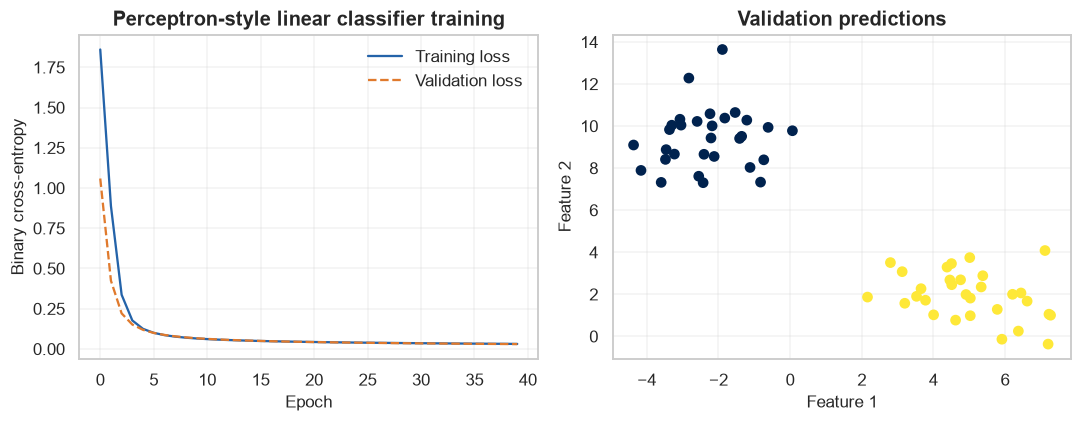

In [3]:
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X, y = make_blobs(n_samples=240, centers=2, cluster_std=1.2, random_state=RANDOM_SEED)
X_train, X_validation, y_train, y_validation = train_test_split(X, y, test_size=.25, stratify=y, random_state=RANDOM_SEED)
model = nn.Linear(2, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=.05)
loss_fn = nn.BCEWithLogitsLoss()
Xt = torch.tensor(X_train, dtype=torch.float32)
yt = torch.tensor(y_train[:, None], dtype=torch.float32)
validation_Xt = torch.tensor(X_validation, dtype=torch.float32)
validation_yt = torch.tensor(y_validation[:, None], dtype=torch.float32)
loss_history = []; validation_loss_history = []
for epoch in range(40):
    model.train()
    optimizer.zero_grad()
    logits = model(Xt)
    loss = loss_fn(logits, yt)
    loss.backward()
    optimizer.step()
    model.eval()
    with torch.no_grad():
        validation_logits = model(validation_Xt)
        validation_loss = loss_fn(validation_logits, validation_yt)
    loss_history.append(loss.item())
    validation_loss_history.append(validation_loss.item())
validation_pred = (validation_logits.squeeze() >= 0).numpy().astype(int)
validation_accuracy = accuracy_score(y_validation, validation_pred)
print("Model diagnostics:", {
    "input_shape": tuple(Xt.shape),
    "intermediate_shape": "not applicable (single affine layer)",
    "output_shape": tuple(logits.shape),
    "trainable_parameters": sum(p.numel() for p in model.parameters()),
    "final_training_loss": round(loss_history[-1], 4),
    "final_validation_loss": round(validation_loss_history[-1], 4),
    "validation_accuracy": round(validation_accuracy, 3),
})

figure, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(loss_history, color=COURSE_COLORS["blue"], label="Training loss")
axes[0].plot(validation_loss_history, color=COURSE_COLORS["orange"], linestyle="--", label="Validation loss")
axes[0].set(title="Perceptron-style linear classifier training", xlabel="Epoch", ylabel="Binary cross-entropy")
axes[0].legend()
axes[1].scatter(X_validation[:,0], X_validation[:,1], c=validation_pred, cmap="cividis")
axes[1].set(title="Validation predictions", xlabel="Feature 1", ylabel="Feature 2")
figure.tight_layout()
plt.show()

**How to interpret the result:** The loss curve shows optimization; the scatter shows that a single linear boundary is sufficient for this dataset.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Too small a learning rate moves slowly; too large can overshoot useful parameters.

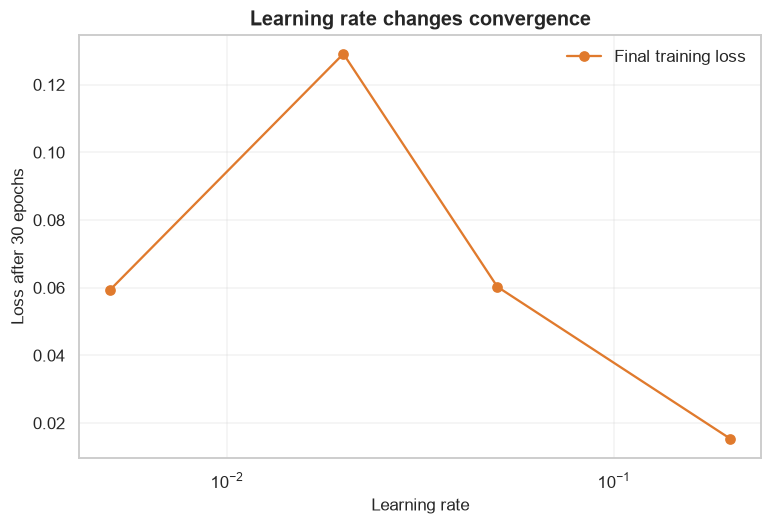

In [4]:
rates = [.005, .02, .05, .2]
final_losses = []
for rate in rates:
    candidate = nn.Linear(2, 1)
    opt = torch.optim.SGD(candidate.parameters(), lr=rate)
    for _ in range(30):
        opt.zero_grad(); candidate_loss = loss_fn(candidate(Xt), yt); candidate_loss.backward(); opt.step()
    final_losses.append(candidate_loss.item())
figure, axis = plt.subplots()
axis.semilogx(rates, final_losses, marker="o", color=COURSE_COLORS["orange"], label="Final training loss")
axis.set(title="Learning rate changes convergence", xlabel="Learning rate", ylabel="Loss after 30 epochs")
axis.legend()
plt.show()

## 18. Common mistakes

            - Forgetting batch and feature dimensions
- Applying softmax before CrossEntropyLoss
- Evaluating on the training set
- Leaving gradients accumulated between optimizer steps

            ## 19. Advantages and disadvantages

            **Advantages**

            - Learns features jointly with predictions
- Flexible building blocks for structured data

            **Disadvantages**

            - Cannot solve nonlinearly separable patterns such as XOR
- Hard threshold outputs are not calibrated probabilities

            ## 20. When to use and when not to use the algorithm

            **Use it when:** the data and task benefit from learned nonlinear representations and validation supports the added complexity.

            **Do not use it when:** a small tabular dataset is handled well by a simpler, easier-to-audit model.

## 21. Exercises

1. **Conceptual:** Why do hidden layers need nonlinear activations?
2. **Mathematical/hand calculation:** Calculate ReLU([−2, 0, 3]).
3. **Coding/experimentation:** Double hidden width and compare parameter count and validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Without nonlinearities, multiple affine layers equal one affine layer.
2. The result is [0, 0, 3].
3. Change the layer width, count parameters, retrain with the same split, and compare training-versus-validation loss rather than training loss alone.

</details>

## 23. Summary and key takeaways

            - Tensor shapes are part of the model specification
- Forward propagation produces predictions and backpropagation produces gradients
- Training and validation curves reveal optimization and generalization

            ## 24. Further reading

            - [PyTorch tutorials](https://pytorch.org/tutorials/)
- [PyTorch neural-network modules](https://pytorch.org/docs/stable/nn.html)